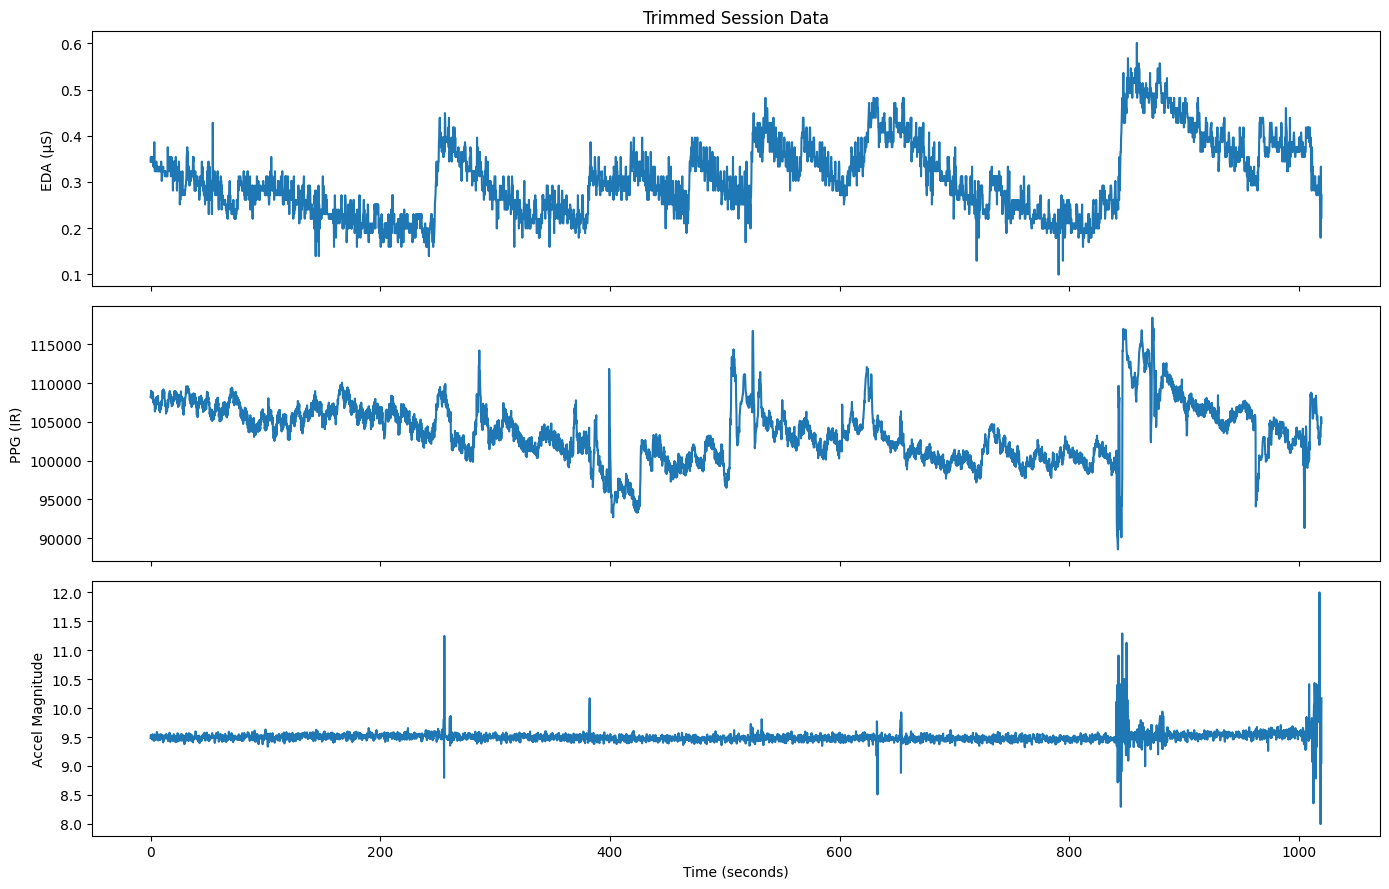

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('session_trimmed.csv')
df['wallclock'] = pd.to_datetime(df['wallclock'])

# Convert to seconds elapsed for easier reading on the x-axis
df['t_sec'] = (df['wallclock'] - df['wallclock'].iloc[0]).dt.total_seconds()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['t_sec'], df['eda_conductance_us'])
axes[0].set_ylabel('EDA (µS)')
axes[0].set_title('Trimmed Session Data')

axes[1].plot(df['t_sec'], df['ppg_ir'])
axes[1].set_ylabel('PPG (IR)')

acc_mag = (df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2) ** 0.5
axes[2].plot(df['t_sec'], acc_mag)
axes[2].set_ylabel('Accel Magnitude')
axes[2].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [2]:
# Check for the signal dropout we identified earlier
low_ppg = df[df['ppg_ir'] < 5000]
print(f"Rows with suspiciously low PPG: {len(low_ppg)}")
if len(low_ppg) > 0:
    print(f"First occurrence at: {low_ppg['wallclock'].iloc[0]}")
    print(f"Last occurrence at: {low_ppg['wallclock'].iloc[-1]}")

Rows with suspiciously low PPG: 0


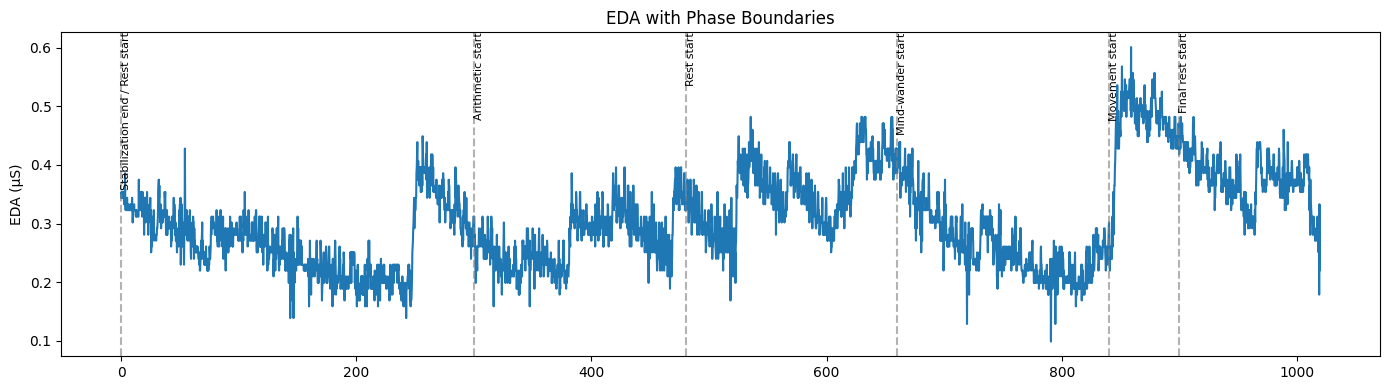

In [3]:
# Example -- replace with your actual noted phase start times
phase_times = {
    'Stabilization end / Rest start': "13:55:00",
    'Arithmetic start': "14:00:00",
    'Rest start': "14:03:00",
    'Mind-wander start': "14:06:00",
    'Movement start': "14:09:00",
    'Final rest start': "14:10:00"
}

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['t_sec'], df['eda_conductance_us'])
ax.set_ylabel('EDA (µS)')
ax.set_title('EDA with Phase Boundaries')

for label, time_str in phase_times.items():
    phase_time = pd.to_datetime(time_str, format="%H:%M:%S").time()
    matching_rows = df[df['wallclock'].dt.time >= phase_time]
    if len(matching_rows) > 0:
        boundary_t = matching_rows['t_sec'].iloc[0]
        ax.axvline(boundary_t, color='gray', linestyle='--', alpha=0.6)
        ax.text(boundary_t, ax.get_ylim()[1], label, 
                rotation=90, fontsize=8, va='top')

plt.tight_layout()
plt.show()

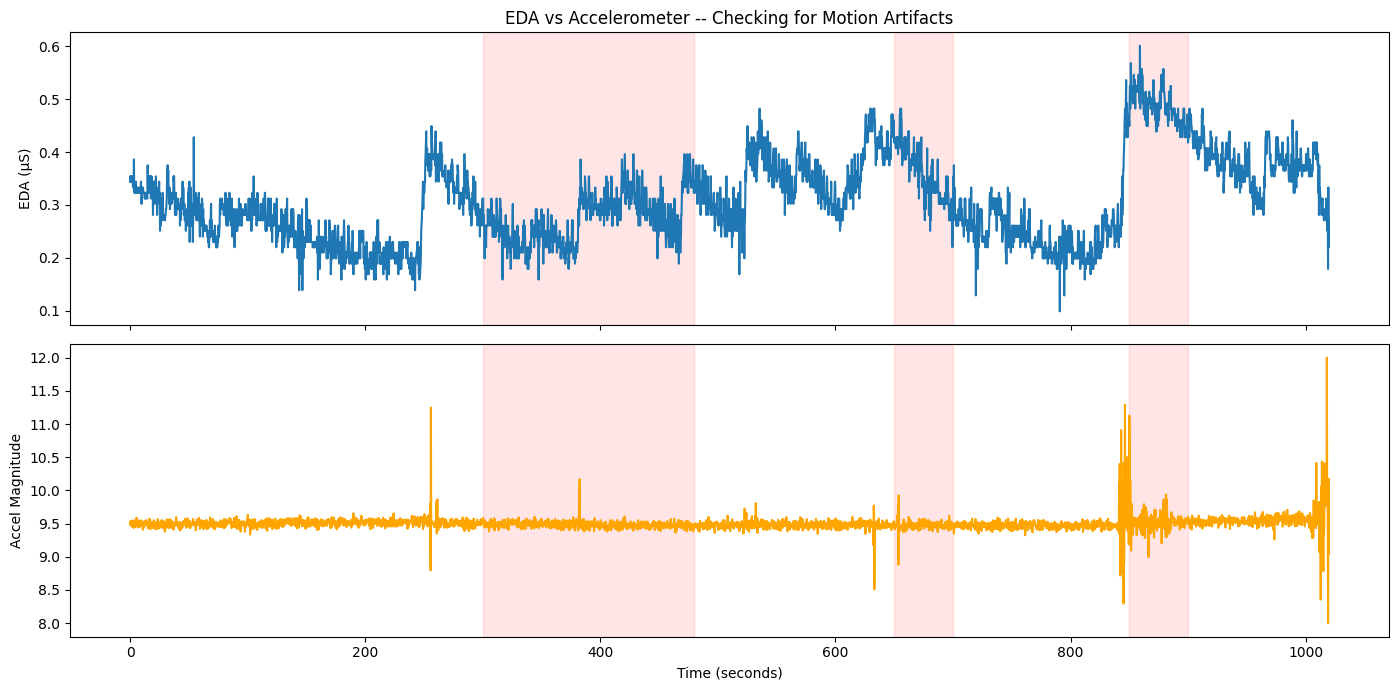

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('session_trimmed.csv')
df['wallclock'] = pd.to_datetime(df['wallclock'])
df['t_sec'] = (df['wallclock'] - df['wallclock'].iloc[0]).dt.total_seconds()

acc_mag = (df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2) ** 0.5

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df['t_sec'], df['eda_conductance_us'])
axes[0].set_ylabel('EDA (µS)')
axes[0].set_title('EDA vs Accelerometer -- Checking for Motion Artifacts')

axes[1].plot(df['t_sec'], acc_mag, color='orange')
axes[1].set_ylabel('Accel Magnitude')
axes[1].set_xlabel('Time (seconds)')

# Mark the specific windows you're questioning
suspicious_windows = [(300, 480), (650, 700), (850, 900)]
for start, end in suspicious_windows:
    for ax in axes:
        ax.axvspan(start, end, color='red', alpha=0.1)

plt.tight_layout()
plt.show()

c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


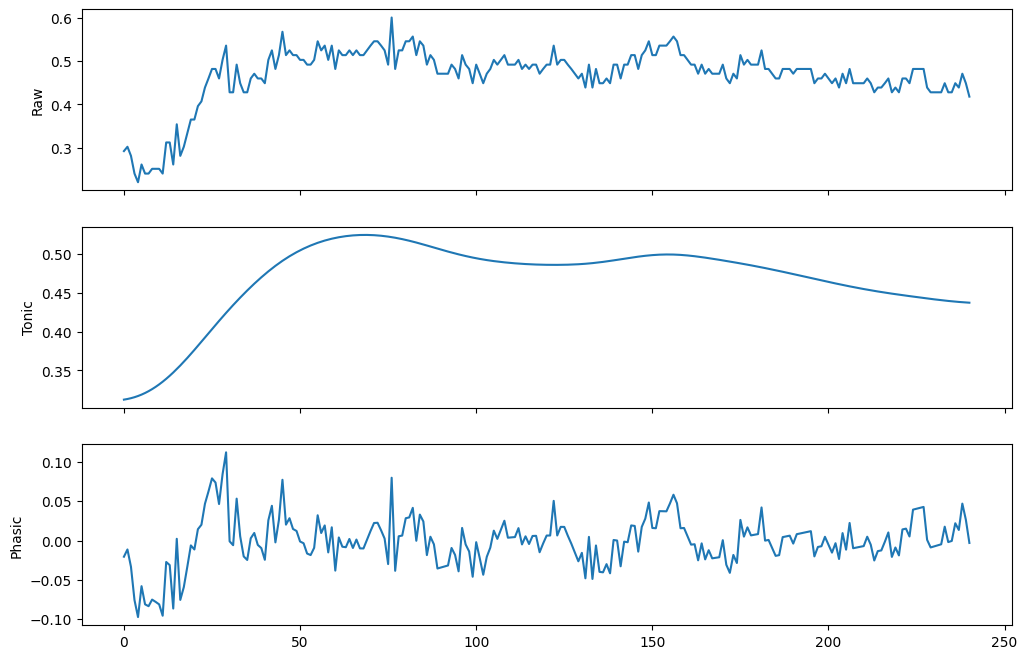

In [5]:
import neurokit2 as nk

# isolate the movement window
movement_mask = (df['t_sec'] >= 840) & (df['t_sec'] <= 900)
movement_eda_raw = df.loc[movement_mask, 'eda_conductance_us'].values

eda_signals, info = nk.eda_process(movement_eda_raw, sampling_rate=4)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(eda_signals['EDA_Raw'])
axes[0].set_ylabel('Raw')
axes[1].plot(eda_signals['EDA_Tonic'])
axes[1].set_ylabel('Tonic')
axes[2].plot(eda_signals['EDA_Phasic'])
axes[2].set_ylabel('Phasic')
plt.show()

In [6]:
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt

# Load your trimmed session
df = pd.read_csv('session_trimmed.csv')
df['wallclock'] = pd.to_datetime(df['wallclock'])
df['t_sec'] = (df['wallclock'] - df['wallclock'].iloc[0]).dt.total_seconds()

# --- Window 1: the movement window you already analyzed ---
movement_mask = (df['t_sec'] >= 840) & (df['t_sec'] <= 900)
movement_eda_raw = df.loc[movement_mask, 'eda_conductance_us'].values

# --- Window 2: a comparison "quiet" window ---
# pick a window of the same length (60 seconds) from a calm period
quiet_mask = (df['t_sec'] >= 500) & (df['t_sec'] <= 560)
quiet_eda_raw = df.loc[quiet_mask, 'eda_conductance_us'].values

print(f"Movement window samples: {len(movement_eda_raw)}")
print(f"Quiet window samples: {len(quiet_eda_raw)}")

Movement window samples: 241
Quiet window samples: 241


In [7]:
# Process movement window
movement_signals, movement_info = nk.eda_process(
    movement_eda_raw, sampling_rate=4
)

# Process quiet window
quiet_signals, quiet_info = nk.eda_process(
    quiet_eda_raw, sampling_rate=4
)

c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


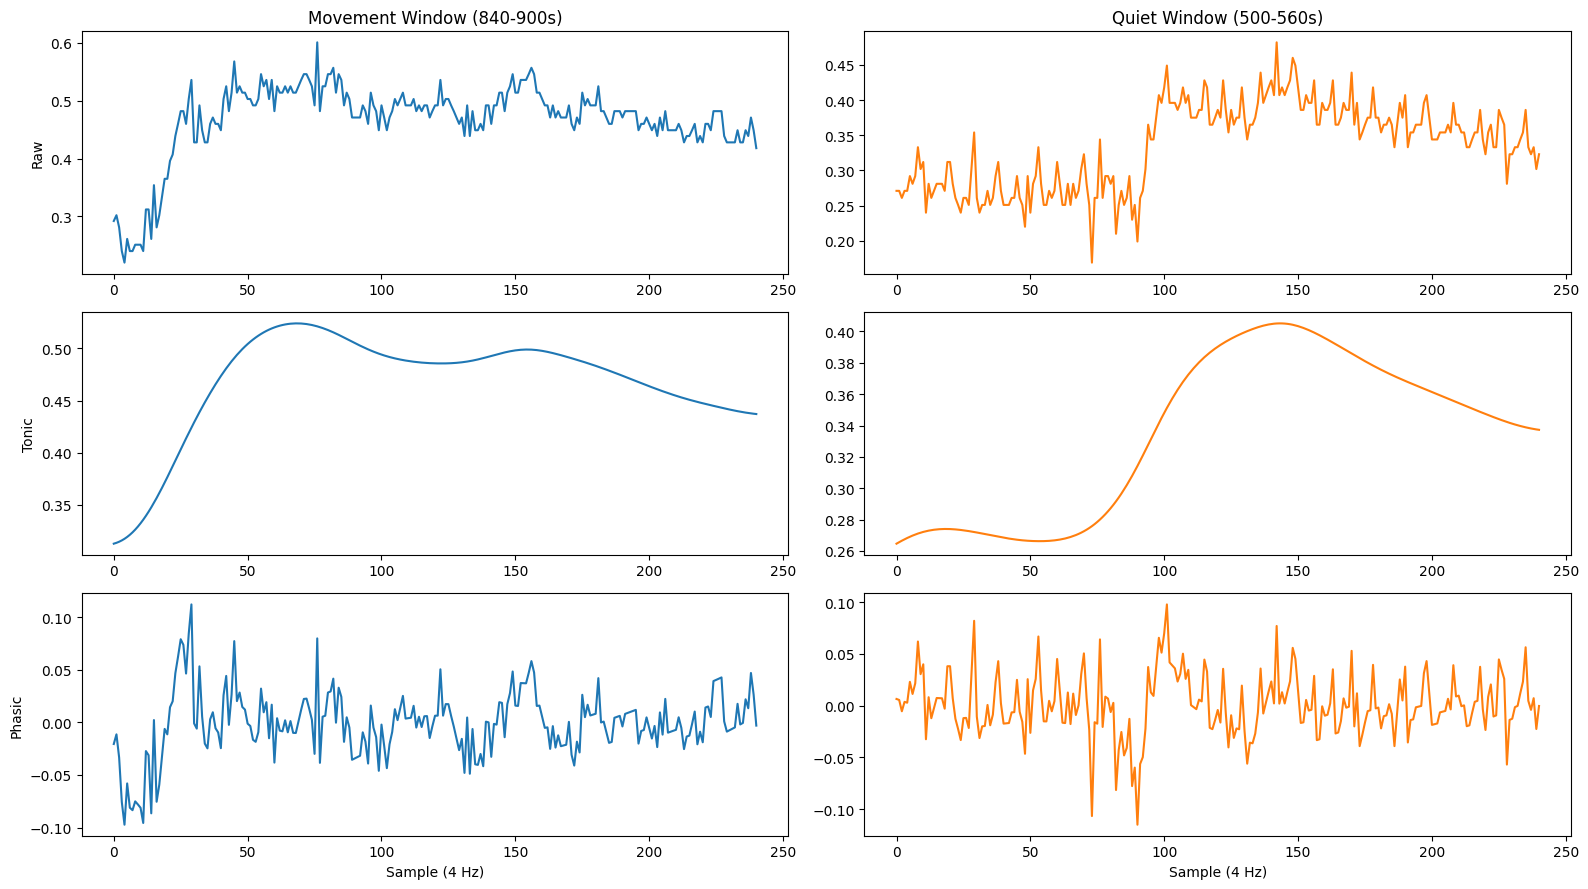

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharex=False)

# Movement window -- left column
axes[0, 0].plot(movement_signals['EDA_Raw'], color='tab:blue')
axes[0, 0].set_ylabel('Raw')
axes[0, 0].set_title('Movement Window (840-900s)')

axes[1, 0].plot(movement_signals['EDA_Tonic'], color='tab:blue')
axes[1, 0].set_ylabel('Tonic')

axes[2, 0].plot(movement_signals['EDA_Phasic'], color='tab:blue')
axes[2, 0].set_ylabel('Phasic')
axes[2, 0].set_xlabel('Sample (4 Hz)')

# Quiet window -- right column
axes[0, 1].plot(quiet_signals['EDA_Raw'], color='tab:orange')
axes[0, 1].set_title('Quiet Window (500-560s)')

axes[1, 1].plot(quiet_signals['EDA_Tonic'], color='tab:orange')

axes[2, 1].plot(quiet_signals['EDA_Phasic'], color='tab:orange')
axes[2, 1].set_xlabel('Sample (4 Hz)')

plt.tight_layout()
plt.show()

In [9]:
def summarize_window(signals, label):
    tonic = signals['EDA_Tonic'].values
    phasic = signals['EDA_Phasic'].values
    scr_count = signals['SCR_Peaks'].sum()
    
    print(f"\n--- {label} ---")
    print(f"Tonic range: {tonic.max() - tonic.min():.4f}")
    print(f"Tonic slope (start to peak): "
          f"{tonic.max() - tonic[0]:.4f}")
    print(f"Phasic std: {phasic.std():.4f}")
    print(f"SCR peaks detected: {scr_count}")
    
    if scr_count > 0:
        peak_amplitudes = signals.loc[
            signals['SCR_Peaks'] == 1, 'SCR_Amplitude'
        ].values
        print(f"Mean SCR amplitude: {peak_amplitudes.mean():.4f}")

summarize_window(movement_signals, "Movement Window")
summarize_window(quiet_signals, "Quiet Window")


--- Movement Window ---
Tonic range: 0.2115
Tonic slope (start to peak): 0.2115
Phasic std: 0.0309
SCR peaks detected: 39
Mean SCR amplitude: 0.0458

--- Quiet Window ---
Tonic range: 0.1405
Tonic slope (start to peak): 0.1405
Phasic std: 0.0297
SCR peaks detected: 43
Mean SCR amplitude: 0.0536


In [10]:
import numpy as np

def compute_window_motion(window_df):
    """
    Computes accelerometer magnitude standard deviation
    for a single window. High values indicate motion.
    """
    acc_mag = np.sqrt(
        window_df['acc_x']**2 + 
        window_df['acc_y']**2 + 
        window_df['acc_z']**2
    )
    return acc_mag.std()

In [11]:
def get_motion_threshold(all_window_motion_values):
    """
    Computes the exclusion threshold for one session,
    based on that session's own distribution of motion values.
    """
    mean_motion = np.mean(all_window_motion_values)
    std_motion = np.std(all_window_motion_values)
    threshold = mean_motion + 2 * std_motion
    return threshold

In [13]:
import pandas as pd
import numpy as np

# Load your trimmed session
df = pd.read_csv('session_trimmed.csv')
df['wallclock'] = pd.to_datetime(df['wallclock'])
df['t_sec'] = (df['wallclock'] - df['wallclock'].iloc[0]).dt.total_seconds()

# Window parameters -- matching your WESAD pipeline
EDA_RATE = 4  # your actual achieved sampling rate, check this matches
WINDOW_SIZE = 60  # seconds
STEP_SIZE = 30    # seconds

SAMPLES_PER_WINDOW = WINDOW_SIZE * EDA_RATE  # 240
SAMPLES_PER_STEP = STEP_SIZE * EDA_RATE      # 120

# Reset index to ensure clean sequential positions
df = df.reset_index(drop=True)

all_windows = []
start = 0

while start + SAMPLES_PER_WINDOW <= len(df):
    end = start + SAMPLES_PER_WINDOW
    window_df = df.iloc[start:end].copy()
    all_windows.append(window_df)
    start += SAMPLES_PER_STEP

print(f"Total windows created: {len(all_windows)}")

Total windows created: 33


In [14]:
# After extracting all windows and their motion values for a session
motion_values = [compute_window_motion(w) for w in all_windows]
threshold = get_motion_threshold(motion_values)

print(f"Motion threshold for this session: {threshold:.4f}")
print(f"Windows before exclusion: {len(all_windows)}")

clean_windows = []
excluded_count = 0

for window, motion in zip(all_windows, motion_values):
    if motion <= threshold:
        clean_windows.append(window)
    else:
        excluded_count += 1

print(f"Windows excluded for motion: {excluded_count}")
print(f"Windows remaining: {len(clean_windows)}")

Motion threshold for this session: 0.2084
Windows before exclusion: 33
Windows excluded for motion: 3
Windows remaining: 30


In [16]:
import numpy as np

def extract_features_from_window(window):
    """
    Extract EDA tonic, phasic, and SCR features from a 
    single windowed DataFrame segment.
    
    Parameters:
    -----------
    window : pd.DataFrame
        Processed EDA signals for one time window, 
        output of nk.eda_process()
    
    Returns:
    --------
    dict : Feature name -> value mapping
    """
    features = {}
    
    # === Tonic features ===
    tonic = window['EDA_Tonic'].values
    features['tonic_mean'] = np.mean(tonic)
    features['tonic_std'] = np.std(tonic)
    features['tonic_min'] = np.min(tonic)
    features['tonic_max'] = np.max(tonic)
    features['tonic_slope'] = np.polyfit(
        np.arange(len(tonic)), tonic, 1)[0]
    features['tonic_range'] = np.max(tonic) - np.min(tonic)
    features['tonic_cv'] = (
        np.std(tonic) / np.mean(tonic) 
        if np.mean(tonic) > 0 else 0
    )
    
    # === Phasic features ===
    phasic = window['EDA_Phasic'].values
    features['phasic_mean'] = np.mean(phasic)
    features['phasic_std'] = np.std(phasic)
    features['phasic_min'] = np.min(phasic)
    features['phasic_max'] = np.max(phasic)
    features['phasic_range'] = np.max(phasic) - np.min(phasic)
    
    # === SCR features ===
    scr_peaks = window['SCR_Peaks'].values
    features['scr_count'] = np.sum(scr_peaks)
    
    peak_amplitudes = window.loc[
        window['SCR_Peaks'] == 1, 'SCR_Amplitude'
    ].values
    
    features['scr_mean_amplitude'] = (
        np.mean(peak_amplitudes) 
        if len(peak_amplitudes) > 0 else 0
    )
    features['scr_mean_rise_time'] = (
        np.mean(window.loc[
            window['SCR_Peaks'] == 1, 'SCR_RiseTime'
        ].values) if len(peak_amplitudes) > 0 else 0
    )
    features['scr_mean_recovery_time'] = (
        np.mean(window.loc[
            window['SCR_Peaks'] == 1, 'SCR_RecoveryTime'
        ].values) if len(peak_amplitudes) > 0 else 0
    )
    
    return features

In [18]:
import neurokit2 as nk
import pandas as pd

# 1. Process each clean window through NeuroKit2
processed_windows = []
for window in clean_windows:
    eda_raw = window['eda_conductance_us'].values
    eda_signals, _ = nk.eda_process(eda_raw, sampling_rate=4)
    processed_windows.append(eda_signals)

# 2. Extract features from each processed window
clean_features = [
    extract_features_from_window(w) for w in processed_windows
]

# 3. Convert to a DataFrame for easier viewing/analysis
feature_df_this_session = pd.DataFrame(clean_features)
print(feature_df_this_session.head())
print(f"\nTotal feature rows: {len(feature_df_this_session)}")

c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\justi\miniconda3\envs\wearable\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWa

   tonic_mean  tonic_std  tonic_min  tonic_max  tonic_slope  tonic_range  \
0    0.312111   0.015234   0.290868   0.341323    -0.000206     0.050454   
1    0.282281   0.019107   0.246098   0.312548    -0.000183     0.066449   
2    0.275089   0.013085   0.247019   0.290679     0.000155     0.043660   
3    0.266649   0.018290   0.229685   0.289206    -0.000237     0.059522   
4    0.239184   0.015915   0.217308   0.272600    -0.000226     0.055292   

   tonic_cv  phasic_mean  phasic_std  phasic_min  phasic_max  phasic_range  \
0  0.048809    -0.000295    0.023257   -0.067838    0.129231      0.197068   
1  0.067687     0.001431    0.024609   -0.065897    0.131880      0.197777   
2  0.047566    -0.001144    0.020094   -0.055815    0.066287      0.122102   
3  0.068591     0.000089    0.022738   -0.094723    0.064870      0.159593   
4  0.066540    -0.000312    0.024332   -0.098861    0.071644      0.170504   

   scr_count  scr_mean_amplitude  scr_mean_rise_time  scr_mean_recovery_ti

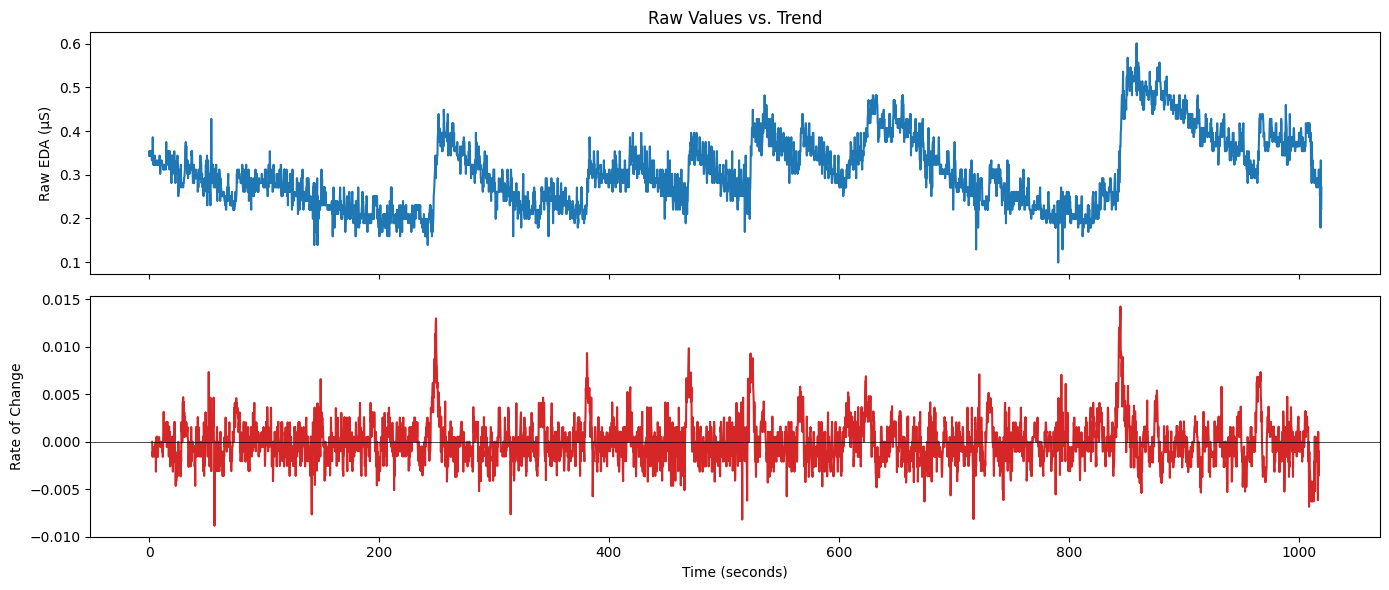

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df['t_sec'], df['eda_conductance_us'])
axes[0].set_ylabel('Raw EDA (µS)')
axes[0].set_title('Raw Values vs. Trend')

# Compute rolling rate of change
rolling_window = 20  # samples, ~5 seconds at 4Hz
eda_smoothed = df['eda_conductance_us'].rolling(
    rolling_window, center=True
).mean()
eda_trend = eda_smoothed.diff()

axes[1].plot(df['t_sec'], eda_trend, color='tab:red')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Rate of Change')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()